# Exploratory Data Analysis using Visualization Assig

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset
df=pd.read_csv('/content/Titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
# Checking there is any missing data.

df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [5]:
# Filling missing values
df['Age'].fillna(df['Age'].mean(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df['Cabin'].fillna(df['Cabin'].mode()[0], inplace=True)

/tmp/ipykernel_11174/2725777730.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
/tmp/ipykernel_11174/2725777730.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

In [6]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


Q1. Create a countplot to show the number of passengers by gender

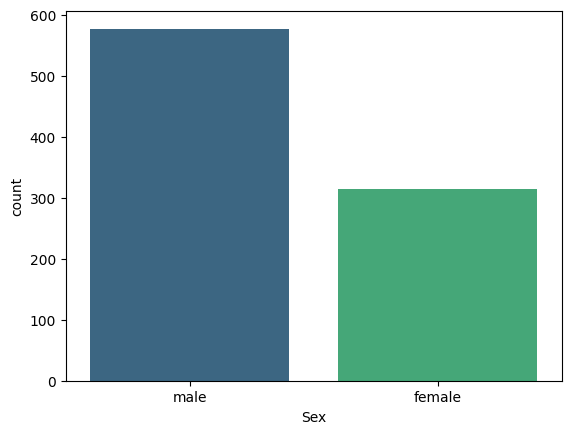

In [7]:
sns.countplot(x='Sex', data=df, hue='Sex', palette='viridis', legend=False)
plt.show()

# Insights
The countplot clearly shows that there are significantly more male passengers than female passengers in the dataset. This imbalance in gender distribution could be a factor in further analysis, especially when looking at survival rates.

Q2. Create a bar chart to show the number of passengers in each passenger class using different colors.

/tmp/ipykernel_11174/869897920.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Pclass', data=df, palette=['Red','Blue','Green'])


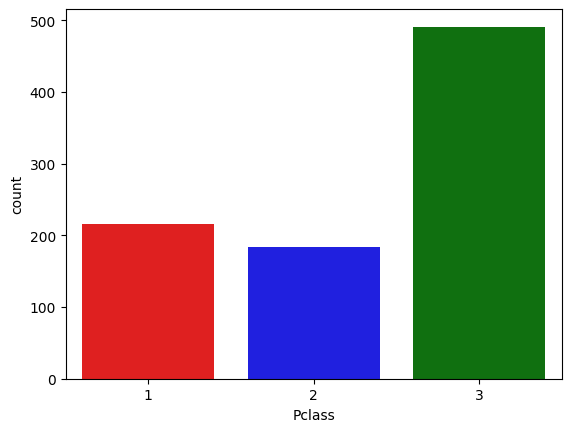

In [8]:
sns.countplot(x='Pclass', data=df, palette=['Red','Blue','Green'])
plt.show()


# Insights
From the bar chart showing passenger classes, we can observe that the majority of passengers were in Pclass 3, followed by Pclass 1, and then Pclass 2. This indicates a higher number of passengers in the lower class compared to the upper classes on the Titanic.

Q3. Create a histogram to show the distribution of passenger age.

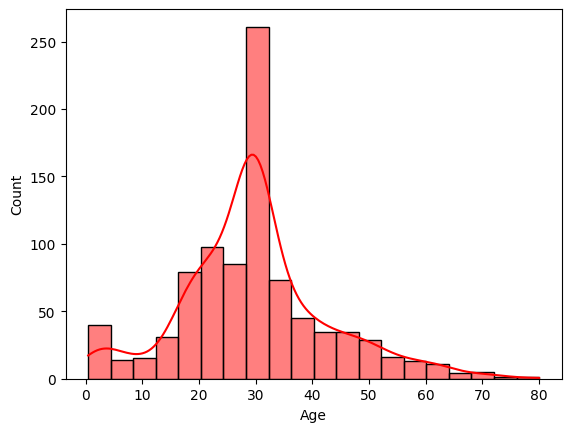

In [9]:
sns.histplot(df['Age'], bins=20, kde=True, color='red')
plt.show()

# Insights
From the histogram, we can see that the majority of passengers are in their 20s and 30s, indicating a relatively young population on board. The distribution appears somewhat right-skewed, with fewer passengers in older age groups. There's also a noticeable peak around the late teens to early twenties, suggesting a significant number of young adults

Q4. Create a boxplot to detect outliers in the fare column

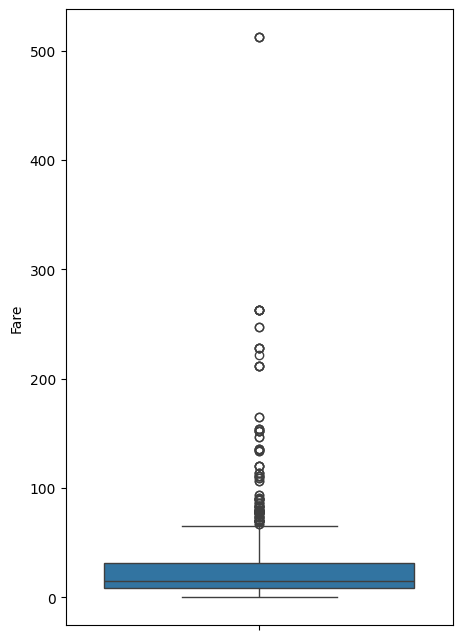

In [10]:
plt.figure(figsize=(5,8))
sns.boxplot(df['Fare'])
plt.show()

# Insights

The boxplot for the 'Fare' column clearly highlights a significant presence of outliers. The box, representing the interquartile range, is relatively compact and situated at lower fare values, indicating that the majority of passengers paid relatively low fares. However, there are numerous individual data points extending far above the upper whisker, which represent passengers who paid exceptionally high fares. This suggests a highly skewed distribution for fare prices, with a few individuals paying significantly more than the average.

Q5. Create a scatterplot to

 a. show the relationship between age and fare.

 b. analyze the relationship between family size (SibSp + Parch) and fare

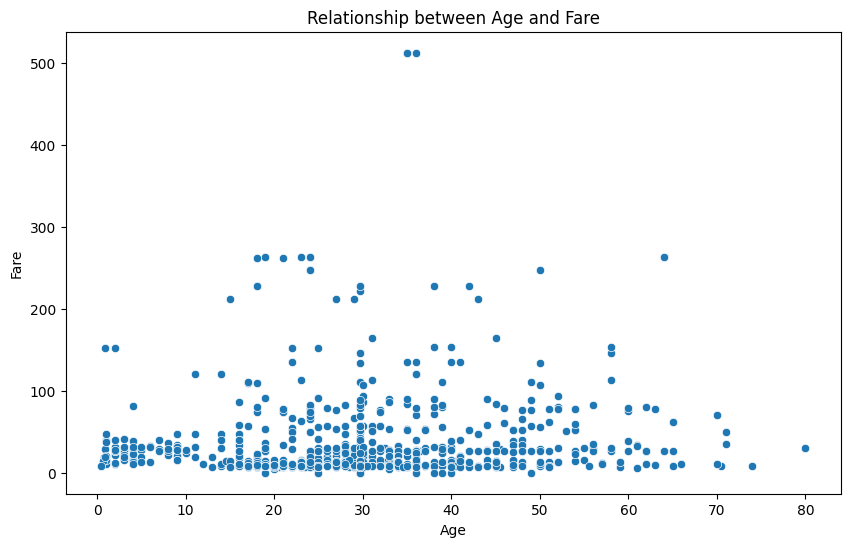

In [11]:
# a

plt.figure(figsize=(10,6))
sns.scatterplot(x='Age', y='Fare', data=df)
plt.title('Relationship between Age and Fare')
plt.show()

# Insights

From the scatterplot showing the relationship between age and fare, it appears that there isn't a strong linear correlation between a passenger's age and the fare they paid. We can see a wide distribution of fares across all age groups. However, it's notable that the highest fares were generally paid by passengers in the adult age range (roughly 20-60 years), while younger and older passengers tend to have paid lower fares. There are also many passengers across all ages who paid very low fares.

<Axes: title={'center': 'Relationship between Family Size and Fare'}, xlabel='None', ylabel='Fare'>

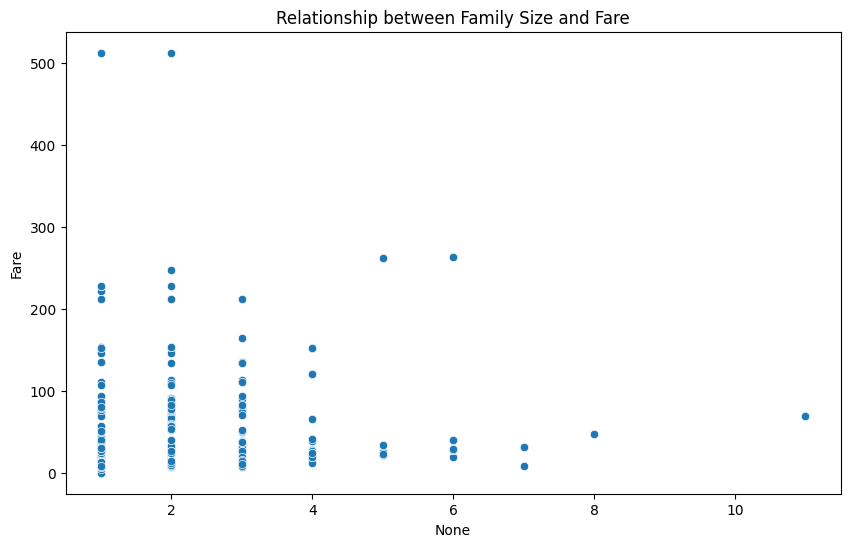

In [12]:
# b
family_size = df['SibSp'] + df['Parch'] + 1
plt.figure(figsize=(10,6))
plt.title('Relationship between Family Size and Fare')
sns.scatterplot(x=family_size, y='Fare', data=df)

# Insights
From the scatterplot, we can observe that most passengers are traveling alone (family size 1) or in small families (2-4 people). These smaller family sizes exhibit a wide range of fares, with some paying very high fares. As family size increases beyond 4, the number of passengers decreases significantly, and the fares paid generally tend to be lower and less varied. This might suggest that larger families, while fewer in number, might have opted for more economical travel options.

 Q6. Create a countplot to show survival count by gender.

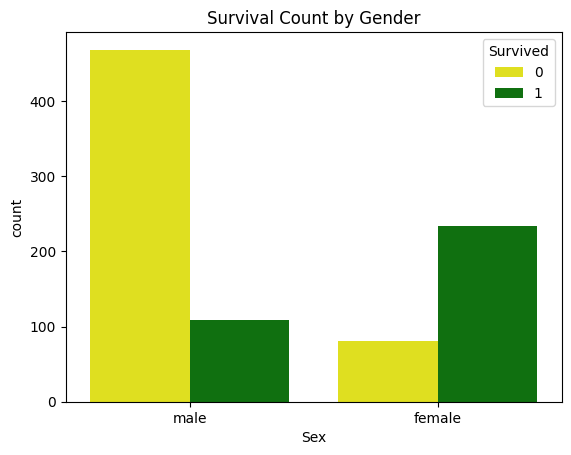

In [17]:
sns.countplot(x='Sex', data=df, hue='Survived', palette=['yellow','green'])
title='Survival Count by Gender'
plt.title(title)
plt.show()


# Insights
The countplot illustrating survival by gender reveals a stark contrast: a significantly higher proportion of females survived compared to males. While the total number of male passengers is greater, the survival rate among them is considerably lower than that of female passengers. This suggests that gender played a crucial role in survival on the Titanic, with females having a much greater chance of surviving.

Q7. Create a bar chart to show survival by passenger class.

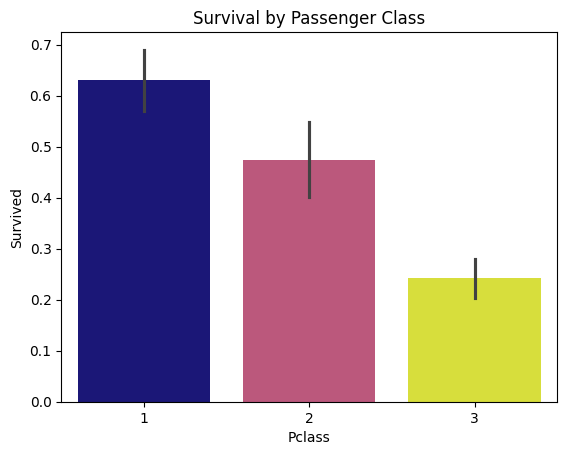

In [20]:
sns.barplot(x='Pclass', y='Survived', data=df, palette='plasma', hue='Pclass', legend=False)
title='Survival by Passenger Class'
plt.title(title)
plt.show()

# Insights
The bar chart clearly indicates that survival rates varied significantly across different passenger classes. Passengers in Pclass 1 (first class) had the highest survival rate, followed by Pclass 2 (second class), and Pclass 3 (third class) had the lowest survival rate. This suggests a strong correlation between social-economic status, represented by passenger class, and the likelihood of survival during the Titanic disaster. Higher class passengers had a considerably better chance of surviving.

Q8. Create a heatmap to show correlation between numerical variables.

In [23]:
df_num=df.select_dtypes(include=['number'])
df_num.head()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,71.2833
2,3,1,3,26.0,0,0,7.9250
3,4,1,1,35.0,1,0,53.1000
4,5,0,3,35.0,0,0,8.0500


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

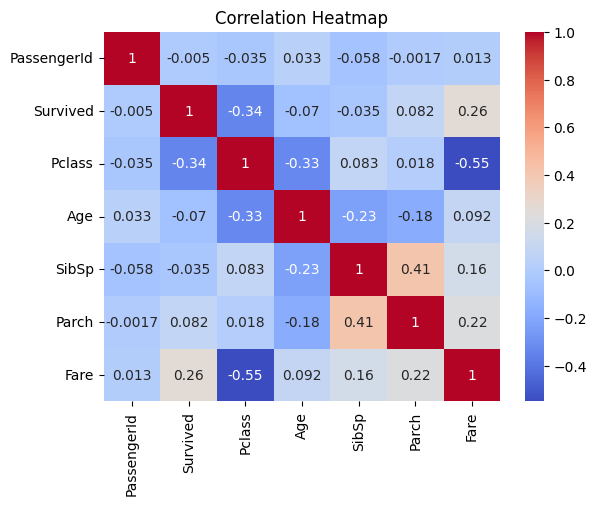

In [24]:
sns.heatmap(df_num.corr(), annot=True, cmap='coolwarm')
title='Correlation Heatmap'
plt.title(title)
plt

# Insights
The heatmap provides valuable insights into the correlations between the numerical variables:

**Survived and Pclass:**
There is a significant negative correlation (-0.34) between Survived and Pclass. This indicates that passengers in lower numerical classes (i.e., higher social-economic classes like 1st class) had a higher chance of survival, which aligns with our previous bar chart observation.

**Survived and Fare:**
A positive correlation (0.26) exists between Survived and Fare, suggesting that passengers who paid higher fares had a better chance of survival.
Survived and Age: The correlation between Survived and Age is very weak (-0.06), implying that age, by itself, did not have a strong linear relationship with survival.

**Fare and Pclass:**
There's a strong negative correlation (-0.55) between Fare and Pclass, which is expected, as higher classes typically have higher fares.
Family Size (SibSp and Parch): SibSp (siblings/spouses aboard) and Parch (parents/children aboard) show a moderate positive correlation with each other (0.41), which is logical as they both relate to family size. Their individual correlations with Survived are quite weak, suggesting that the sheer number of siblings/spouses or parents/children alone isn't a strong predictor of survival in a linear fashion, though family structure might still be relevant.

In summary, the strongest predictors of survival among these numerical variables are Pclass and Fare

Q9. Identify which passenger class paid the highest fare on average.

/tmp/ipykernel_11174/1921963850.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Fare', data=df, palette='plasma')


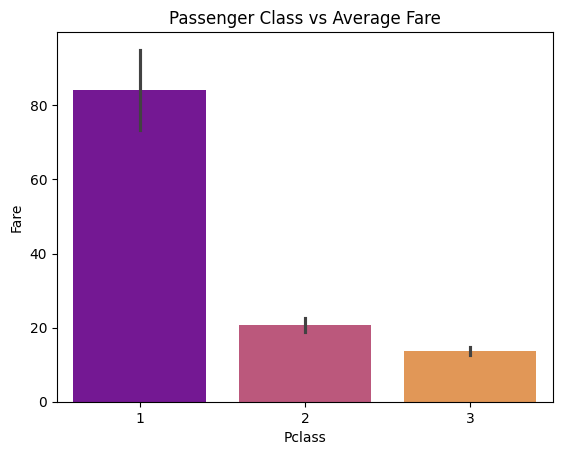

In [25]:
sns.barplot(x='Pclass', y='Fare', data=df, palette='plasma')
title='Passenger Class vs Average Fare'
plt.title(title)
plt.show()

The bar plot clearly shows that passengers in Pclass 1 (first class) paid the highest average fare. This is significantly higher than the average fares paid by passengers in Pclass 2 and Pclass 3.

 This reinforces the idea that Pclass is directly related to the Fare paid, as observed in the correlation heatmap.

Q10. Write at least 5 insights from the dataset based on your visualizations.

### Key Insights from Visualizations

1.  **Gender Disparity in Survival:** A significantly higher proportion of female passengers survived compared to males, indicating gender played a crucial role in survival. The survival rate among males was considerably lower.
2.  **Passenger Class and Survival:** There is a strong correlation between passenger class and survival probability. Passengers in Pclass 1 had the highest survival rate, followed by Pclass 2, and then Pclass 3 had the lowest survival rate, suggesting socioeconomic status was a major factor.
3.  **Age Distribution:** The majority of passengers were in their 20s and 30s, indicating a relatively young population on board. There were fewer passengers in older age groups.
4.  **Fare Outliers and Class-Fare Relationship:** The 'Fare' column shows a significant presence of outliers, with a few passengers paying exceptionally high fares. This directly correlates with passenger class, as Pclass 1 passengers paid the highest average fares, reinforcing that higher classes paid significantly more.
5.  **Weak Correlation of Age and Family Size with Survival (Numerically):** While age and family size (SibSp + Parch) were explored, their linear correlation with survival was relatively weak compared to factors like gender and passenger class. Family size primarily showed that most passengers traveled alone or in small groups, with larger families being less common and generally paying lower fares.